In [1]:
# R Environment (must be set BEFORE importing rpy2)
import os
os.environ['R_HOME'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R'
os.environ['R_LIBS'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R/library'
os.environ['R_LIBS_USER'] = '/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/R/library'

# Python Packages
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

print(f"\nscanpy: {sc.__version__}")
print(f"numpy: {np.__version__}")
print(f"pandas: {pd.__version__}")
print("✓ Python packages loaded")

# rpy2 Setup
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
print(f"\n✓ rpy2 loaded | {ro.r('R.version$version.string')[0]}")

ro.r('suppressPackageStartupMessages(library(lme4))')
lme4_ver = ro.r('as.character(packageVersion("lme4"))')[0]
print(f"✓ R packages: lme4 {lme4_ver}")

/users/PAS2598/ggaitos/.conda/envs/omicverse/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]



scanpy: 1.11.5
numpy: 2.2.6
pandas: 2.3.3
✓ Python packages loaded

✓ rpy2 loaded | R version 4.5.1 (2025-06-13)


R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: package ‘lme4’ was built under R version 4.5.2 
  


✓ R packages: lme4 1.1.38


In [2]:
import matplotlib.pyplot as plt

try:
    import scanpy as sc
    sc.settings.verbosity = 1
    sc.settings.set_figure_params(dpi=150, dpi_save=300, facecolor='white', frameon=False)
except ImportError:
    pass

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.linewidth': 1.0,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
})

SEX_COLORS = {'Male': '#5D6D7E', 'Female': '#A569BD'}

STUDY_GROUP_COLORS = {
    'Age_20_29': '#2E86AB', 'Age_30_39': '#4A90E2', 'Age_40_49': '#50C878',
    'Age_50_59': '#FFB347', 'Age_60_69': '#FF8C00', 'Age_70_79': '#E24A4A',
    'Age_80_100': '#8B0000',
    'Control': '#4E79A7', 'MCI': '#F28E2B', 'AD': '#E15759', 'NCI': '#4E79A7',
    'Young_Healthy_Control': '#4E79A7', "YHC": '#4E79A7', 'Old_Healthy_Control': '#59A14F', "HC": '#59A14F',
    'Old_AD': '#E15759',
}

STUDY_GROUP_ORDER = ['Age_20_29', 'Age_30_39', 'Age_40_49', 'Age_50_59',
                     'Age_60_69', 'Age_70_79', 'Age_80_100']

COHORT_COLORS = {'MSSM': '#2E86AB', 'HBCC': '#E24A4A', 'RUSH': '#50C878',
                 'PsychAD': '#2E86AB', 'PsychENCODE': '#E24A4A',
                 'ROSMAP': '#50C878', 'Mathys': '#FFB347'}

CELL_TYPE_COLORS = {
    'EN': '#0072B2', 'Excitatory': '#0072B2', 'excitatory': '#0072B2',
    'IN': '#E69F00', 'Inhibitory': '#E69F00', 'inhibitory': '#E69F00',
    'Astro': '#009E73', 'Astrocyte': '#009E73', 'Astrocytes': '#009E73',
    'Oligo': '#56B4E9', 'Oligodendrocyte': '#56B4E9', 'Oligodendrocytes': '#56B4E9',
    'OPC': '#CC79A7', 'OPCs': '#CC79A7',
    'Micro': '#D55E00', 'Microglia': '#D55E00',
    'Endo': '#7F7F7F', 'Endothelial': '#7F7F7F',
    'Vascular': '#7F7F7F', 'vascular': '#7F7F7F',
    'PVM': '#D37295', 'Pericyte': '#999999', 'Mural': '#999999',
    'VSMC': '#9C755F', 'VLMC': '#BAB0AC', 'OVM': '#9C755F',
    'Adaptive': '#FABFD2', 'Immune': '#B6992D', 'immune': '#B6992D',
}

SEX_COLORS = {'Male': '#5D6D7E', 'Female': '#A569BD',
              'male': '#5D6D7E', 'female': '#A569BD',
              'M': '#5D6D7E', 'F': '#A569BD',
              'm': '#5D6D7E', 'f': '#A569BD',
              '0': '#5D6D7E', '1': '#A569BD', 0: '#5D6D7E', 1: '#A569BD'}

PALETTES = {'sex': SEX_COLORS, 'study_group': STUDY_GROUP_COLORS,
            'cohort': COHORT_COLORS, 'cell_type': CELL_TYPE_COLORS}

COHORT_COLORS['PsychEncode'] = '#67000D'
COHORT_COLORS['PsychAD'] = '#08306B'
COHORT_COLORS['Mathys']  = '#67000D'

PALETTES['cohort'] = COHORT_COLORS

def color_for(variable, levels, missing='#808080'):
    pal = PALETTES[variable]
    out = [pal.get(str(lv), missing) for lv in levels]
    gaps = [str(lv) for lv, c in zip(levels, out) if c == missing]
    if gaps:
        print(f"WARNING: no {variable} color for {sorted(set(gaps))}, using grey")
    return out

print("✓ Figure settings and palettes configured")

✓ Figure settings and palettes configured


# Figure 2A

 cell_type direction  n_genes  colour  total_tested      comparison
      OPCs      Down       45 #4E79A7         12673 SnCvsNonSnC_all
      OPCs        Up      318 #9370DB         12673 SnCvsNonSnC_all
Astrocytes      Down       28 #E1812C         14086 SnCvsNonSnC_all
Astrocytes        Up      284 #C44E52         14086 SnCvsNonSnC_all


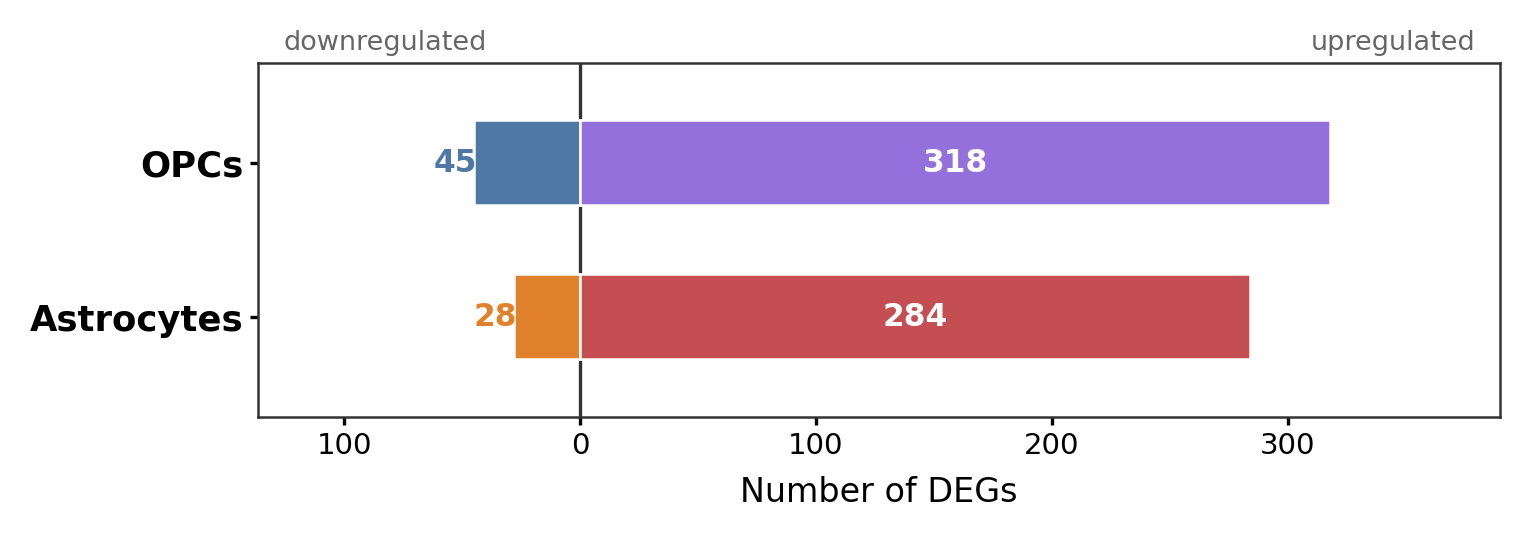

In [3]:
# Figure 2A
SRC        = 'results/fig2A_source_data.csv'
CT_ORDER   = ['OPCs', 'Astrocytes']        # top to bottom
BAR_H      = 0.55
LABEL_IN   = 60                            # counts >= this are drawn inside the bar
FIGSIZE    = (5.2, 1.9)
FS         = 8

import numpy as np, pandas as pd, matplotlib.pyplot as plt

d = pd.read_csv(SRC)
print(d.to_string(index=False))

# signed x: Down to the left, Up to the right
d['x'] = np.where(d.direction == 'Down', -d.n_genes, d.n_genes)
piv    = d.pivot(index='cell_type', columns='direction', values='x').reindex(CT_ORDER)
col    = d.set_index(['cell_type', 'direction']).colour

fig, ax = plt.subplots(figsize=FIGSIZE)
y = np.arange(len(CT_ORDER))

for i, ct in enumerate(CT_ORDER):
    for dr in ('Down', 'Up'):
        v = piv.loc[ct, dr]
        c = col[(ct, dr)]
        ax.barh(y[i], v, height=BAR_H, color=c, edgecolor='white', lw=0.6, zorder=2)
        n = abs(int(v))
        inside = n >= LABEL_IN
        ax.text(v * (0.5 if inside else 1) + (0 if inside else np.sign(v) * 8),
                y[i], f'{n}', ha='center', va='center', fontsize=FS - 0.5,
                fontweight='bold', color='white' if inside else c, zorder=3)

ax.axvline(0, color='#333', lw=0.8, zorder=1)
ax.set_yticks(y); ax.set_yticklabels(CT_ORDER, fontsize=FS + 0.5, fontweight='bold')
ax.set_ylim(len(CT_ORDER) - 0.35, -0.65)

lim = np.ceil(d.n_genes.max() / 50) * 50 + 40
ax.set_xlim(-lim * 0.35, lim)
ticks = [t for t in np.arange(-200, lim + 1, 100) if -lim * 0.35 <= t <= lim]
ax.set_xticks(ticks); ax.set_xticklabels([f'{abs(int(t))}' for t in ticks], fontsize=FS - 1)
ax.set_xlabel('Number of DEGs', fontsize=FS)
ax.tick_params(length=2, pad=1.5)

for sp in ax.spines.values():                 # full border
    sp.set_visible(True)
    sp.set_linewidth(0.6)
    sp.set_color('#333333')

ax.text(0.02, 1.02, 'downregulated', transform=ax.transAxes, fontsize=FS - 1.5,
        color='#666', ha='left', va='bottom')
ax.text(0.98, 1.02, 'upregulated', transform=ax.transAxes, fontsize=FS - 1.5,
        color='#666', ha='right', va='bottom')

fig.tight_layout()
plt.show()

# Figure 2B

region     OPC_only  shared  Astrocyte_only
direction                                  
Down             44       1              27
Up              286      32             252

circle totals
  Down  OPC 45   Astrocyte 28
  Up    OPC 318   Astrocyte 284


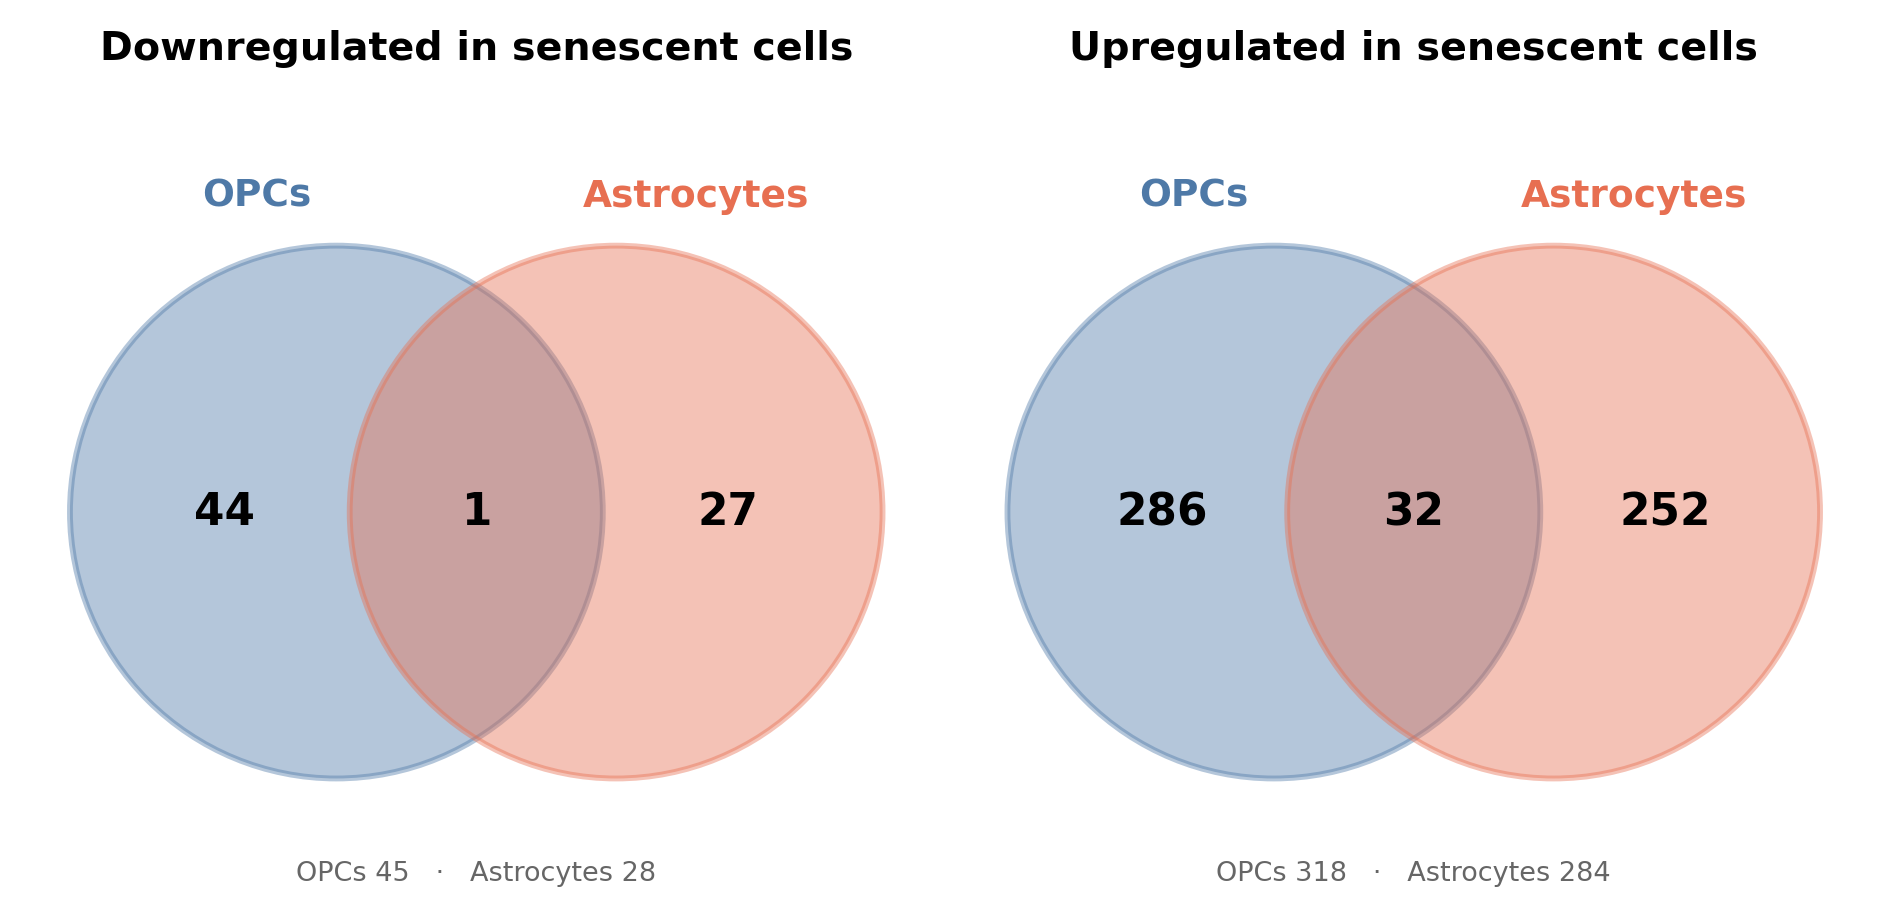

In [4]:
# Figure 2B
SRC        = 'results/fig2B_source_data.csv'
DIRECTIONS = ['Down', 'Up']
SET_ORDER  = ['OPCs', 'Astrocytes']          # left circle, right circle
SET_COLORS = {'OPCs': '#4E79A7', 'Astrocytes': '#E76F51'}
R, DX      = 1.0, 1.05                       # radius, centre separation
FIGSIZE    = (6.4, 3.0)
FS         = 8

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Circle

d = pd.read_csv(SRC)
tab = (d.groupby(['direction', 'region']).size().unstack()
       [['OPC_only', 'shared', 'Astrocyte_only']].reindex(DIRECTIONS))
print(tab.to_string())
print('\ncircle totals')
for dr in DIRECTIONS:
    o, s, a = tab.loc[dr]
    print(f'  {dr:5s} OPC {o+s}   Astrocyte {a+s}')

fig, axes = plt.subplots(1, len(DIRECTIONS), figsize=FIGSIZE)
for ax, dr in zip(np.atleast_1d(axes), DIRECTIONS):
    o, s, a = (int(v) for v in tab.loc[dr])
    for cx, ct in ((-DX/2, SET_ORDER[0]), (DX/2, SET_ORDER[1])):
        ax.add_patch(Circle((cx, 0), R, facecolor=SET_COLORS[ct], alpha=0.42,
                            edgecolor=SET_COLORS[ct], lw=1.4, zorder=2))
    ax.text(-DX/2 - R*0.42, 0, f'{o:,}', ha='center', va='center',
            fontsize=FS + 2.5, fontweight='bold', zorder=3)
    ax.text(0, 0, f'{s:,}', ha='center', va='center',
            fontsize=FS + 2.5, fontweight='bold', zorder=3)
    ax.text(DX/2 + R*0.42, 0, f'{a:,}', ha='center', va='center',
            fontsize=FS + 2.5, fontweight='bold', zorder=3)

    ax.text(-DX/2 - R*0.30, R*1.12, SET_ORDER[0], ha='center', va='bottom',
            fontsize=FS + 1, fontweight='bold', color=SET_COLORS[SET_ORDER[0]])
    ax.text( DX/2 + R*0.30, R*1.12, SET_ORDER[1], ha='center', va='bottom',
            fontsize=FS + 1, fontweight='bold', color=SET_COLORS[SET_ORDER[1]])
    ax.set_title(f'{dr}regulated in senescent cells',
                 fontsize=FS + 1.5, fontweight='bold', pad=16)
    ax.text(0.5, -0.06, f'{SET_ORDER[0]} {o+s:,}   ·   {SET_ORDER[1]} {a+s:,}',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=FS - 1.5, color='#666')

    ax.set_xlim(-DX/2 - R*1.15, DX/2 + R*1.15)
    ax.set_ylim(-R*1.15, R*1.45)
    ax.set_aspect('equal'); ax.axis('off')

fig.tight_layout()
plt.show()

# Figure 2C

14,086 genes   significant 312
direction
Up      284
Down     28
labelled 10 genes (adjustText)


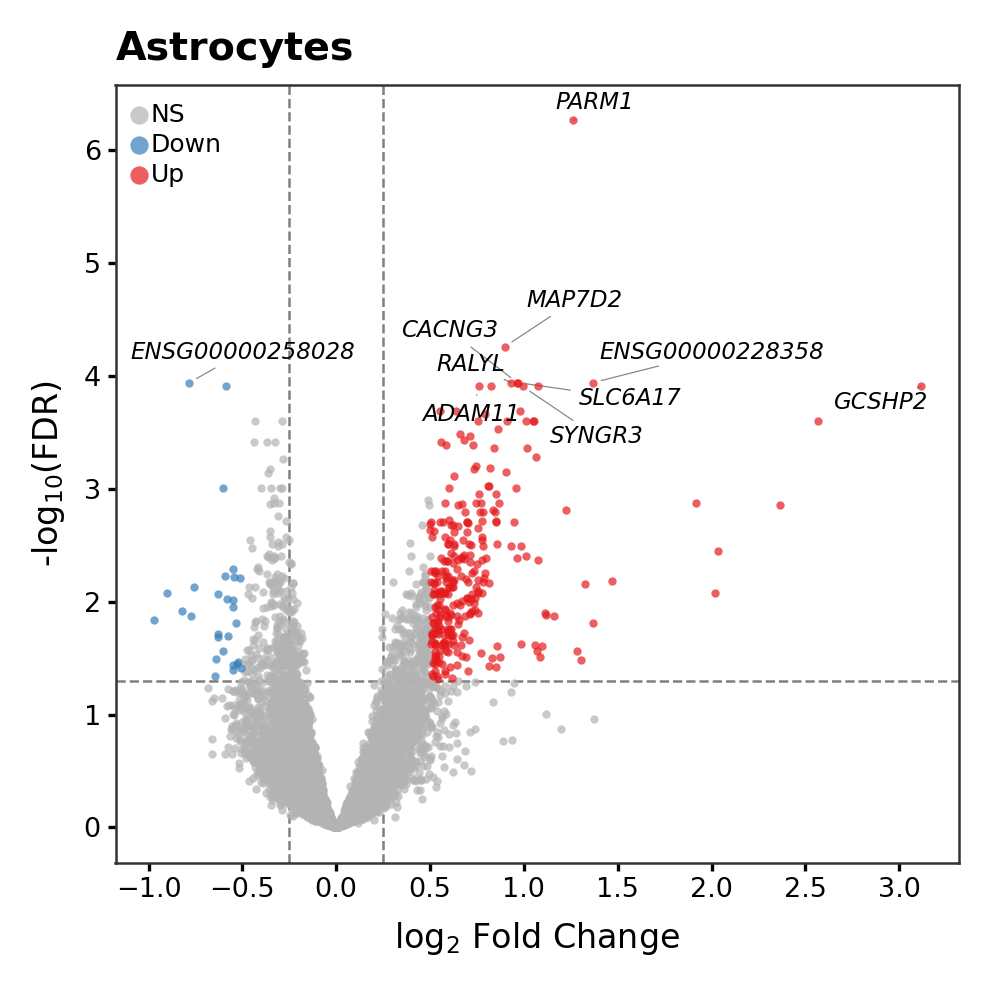

In [5]:
# Figure 2C
SRC        = 'results/fig2C_source_data.csv.gz'
TITLE      = 'Astrocytes'
PT_COLORS  = {'Up': '#E41A1C', 'Down': '#377EB8', 'NS': '#B3B3B3'}
Z_ORDER    = {'NS': 1, 'Down': 2, 'Up': 3}       # significant drawn on top
FDR_THRESHOLD, LFC_THRESHOLD = 0.05, 0.25
S_PT, ALPHA = 4.0, 0.7
LAB_SIZE   = 5.5
FIGSIZE    = (3.4, 3.4)
FS         = 8
SEED       = 0

import numpy as np, pandas as pd, matplotlib.pyplot as plt

d = pd.read_csv(SRC)
print(f'{len(d):,} genes   significant {int(d.significant.astype(bool).sum())}')
print(d[d.significant.astype(bool)].direction.value_counts().to_string())

fig, ax = plt.subplots(figsize=FIGSIZE)

for dr in sorted(PT_COLORS, key=Z_ORDER.get):
    s = d[d.direction == dr]
    if s.empty: continue
    ax.scatter(s.avg_log2FC, s.neg_log10_padj, s=S_PT, c=PT_COLORS[dr],
               alpha=ALPHA, lw=0, rasterized=True, zorder=Z_ORDER[dr], label=dr)

ax.axhline(-np.log10(FDR_THRESHOLD), ls='--', color='grey', lw=0.6, zorder=0)
for v in (-LFC_THRESHOLD, LFC_THRESHOLD):
    ax.axvline(v, ls='--', color='grey', lw=0.6, zorder=0)

# ── labels ────────────────────────────────────────────────────────────────
lab = d[d.label.fillna('') != '']
texts = [ax.text(r.avg_log2FC, r.neg_log10_padj, r.label, fontsize=LAB_SIZE,
                 fontstyle='italic', ha='center', va='bottom', zorder=5)
         for _, r in lab.iterrows()]
try:
    from adjustText import adjust_text
    adjust_text(texts, ax=ax, force_text=(0.3, 0.5), expand=(1.15, 1.35),
                arrowprops=dict(arrowstyle='-', color='#888', lw=0.3))
    print(f'labelled {len(texts)} genes (adjustText)')
except ImportError:
    rng = np.random.default_rng(SEED)
    for t in texts:
        x, y = t.get_position()
        t.set_position((x + rng.uniform(-0.06, 0.06), y + rng.uniform(0.4, 1.2)))
    print(f'labelled {len(texts)} genes (adjustText unavailable — jittered)')

ax.set_xlabel('log$_2$ Fold Change', fontsize=FS)
ax.set_ylabel('-log$_{10}$(FDR)', fontsize=FS)
ax.set_title(TITLE, fontsize=FS + 1.5, fontweight='bold', loc='left')
ax.tick_params(labelsize=FS - 1.5, length=2, pad=1.5)

for sp in ax.spines.values():                 # full border
    sp.set_visible(True); sp.set_linewidth(0.6); sp.set_color('#333333')

ax.legend(fontsize=FS - 2, frameon=False, loc='upper left',
          handletextpad=0.2, borderpad=0.2, labelspacing=0.25,
          markerscale=2.2)

fig.tight_layout()
plt.show()

# Figure 2D

In [6]:
# Figure 2D — Sankey  (Direction -> Pathway -> Category)
SRC       = 'results/fig2D_source_data.csv'
OUT_HTML  = 'results/fig2D_sankey.html'
CELL_TYPE = 'Astrocytes'
DIR_ORDER = ['SnC', 'Non-SnC']            # upregulated TOP, downregulated BOTTOM
CAT_ORDER = ['Protein Synthesis / RNA Biology', 'Synaptic / Neural Function',
             'Proteostasis & Cytoskeleton', 'Stress / Immune / Environmental Response',
             'Cell Structure / Adhesion / ECM']      # down-only category last
DIR_LABEL = {'SnC': 'Upregulated<br>in senescent cells',
             'Non-SnC': 'Downregulated<br>in senescent cells'}
LINK_VALUE = 'uniform'                    # 'uniform' | 'genes'
MAX_PATHWAY_LEN = 45
X_DIR, X_PATH, X_CAT = 0.01, 0.42, 0.99

DIR_NODE = {'SnC': 'rgba(244, 177, 190, 0.95)', 'Non-SnC': 'rgba(60, 100, 150, 0.95)'}
DIR_LINK = {'SnC': 'rgba(244, 177, 190, 0.55)', 'Non-SnC': 'rgba(60, 100, 150, 0.55)'}
PATH_NODE = 'rgba(120, 170, 210, 0.95)'
CAT_COLORS = {
    'Protein Synthesis / RNA Biology':          'rgba(110, 170, 215, 0.95)',
    'Synaptic / Neural Function':               'rgba(244, 162,  97, 0.95)',
    'Proteostasis & Cytoskeleton':              'rgba(138, 177, 125, 0.95)',
    'Stress / Immune / Environmental Response': 'rgba(231, 111,  81, 0.95)',
    'Cell Structure / Adhesion / ECM':          'rgba(155, 130, 200, 0.95)',
}
FIG_W, FIG_H = 1000, 560

import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

d  = pd.read_csv(SRC)
pw = (d.groupby(['pathway', 'category', 'direction'], as_index=False)
        .agg(n_genes=('gene', 'nunique'), NES=('NES', 'first'), FDR=('FDR', 'first')))

DIR_RANK = {k: i for i, k in enumerate(DIR_ORDER)}
CAT_RANK = {c: i for i, c in enumerate(CAT_ORDER)}
pw['_d'] = pw.direction.map(DIR_RANK)
pw['_c'] = pw.category.map(CAT_RANK)
pw = pw.sort_values(['_d', '_c', 'NES'], ascending=[True, True, False])
print(f'{len(pw)} pathways   {pw.category.nunique()} categories')
print(pw[['direction', 'category', 'pathway', 'NES']].to_string(index=False))

def wrap(t, n=MAX_PATHWAY_LEN):
    if len(t) <= n: return t
    words, lines, cur = t.split(), [], ''
    for w in words:
        if len(cur) + len(w) + 1 <= n: cur += (' ' if cur else '') + w
        else:
            if cur: lines.append(cur)
            cur = w
    if cur: lines.append(cur)
    return '<br>'.join(lines[:2])

pw['label'] = pw.pathway.apply(wrap)
pw['val']   = 1 if LINK_VALUE == 'uniform' else pw.n_genes

dirs   = [k for k in DIR_ORDER if k in set(pw.direction)]
paths  = list(pw.label)                                    # already top-to-bottom
cats   = [c for c in CAT_ORDER if c in set(pw.category)]
labels = [DIR_LABEL[k] for k in dirs] + paths + cats

di = {k: i for i, k in enumerate(dirs)}
pi = {p: i + len(dirs) for i, p in enumerate(paths)}
ci = {c: i + len(dirs) + len(paths) for i, c in enumerate(cats)}

# arm height proportional to its share, stacked top-to-bottom in DIR_ORDER
share = pw.groupby('direction').val.sum() / pw.val.sum()
node_x, node_y, node_col = [], [], []
cum = 0.0
for k in dirs:
    node_x.append(X_DIR); node_y.append(cum + share[k] / 2); cum += share[k]
    node_col.append(DIR_NODE[k])
for i, _ in enumerate(paths):
    node_x.append(X_PATH); node_y.append((i + .5) / len(paths))
    node_col.append(PATH_NODE)
for i, c in enumerate(cats):
    node_x.append(X_CAT); node_y.append(.06 + i * .88 / max(len(cats) - 1, 1))
    node_col.append(CAT_COLORS.get(c, 'rgba(150,150,150,0.95)'))

src, tgt, val, lcol = [], [], [], []
for _, r in pw.iterrows():                       # direction -> pathway
    src.append(di[r.direction]); tgt.append(pi[r.label]); val.append(r.val)
    lcol.append(DIR_LINK[r.direction])
for _, r in pw.iterrows():                       # pathway -> category
    src.append(pi[r.label]); tgt.append(ci[r.category]); val.append(r.val)
    lcol.append(CAT_COLORS[r.category].replace('0.95', '0.55'))

fig = go.Figure(go.Sankey(
    arrangement='fixed',
    node=dict(label=labels, x=node_x, y=node_y, color=node_col,
              pad=10, thickness=16,
              line=dict(color='rgba(255,255,255,0.9)', width=0.6)),
    link=dict(source=src, target=tgt, value=val, color=lcol)))

fig.update_layout(font=dict(size=11), width=FIG_W, height=FIG_H,
                  margin=dict(l=10, r=10, t=20, b=20), paper_bgcolor='white')

Path(OUT_HTML).parent.mkdir(parents=True, exist_ok=True)
fig.write_html(OUT_HTML, include_plotlyjs=True, full_html=True)
print(f'\nsaved -> {OUT_HTML}  ({Path(OUT_HTML).stat().st_size/1e6:.1f} MB)')

11 pathways   4 categories
direction                        category                                                                         pathway     NES
      SnC Protein Synthesis / RNA Biology                                  Eukaryotic Translation Elongation R-HSA-156842  2.1675
      SnC Protein Synthesis / RNA Biology                                           Peptide Chain Elongation R-HSA-156902  2.1085
      SnC Protein Synthesis / RNA Biology                                                     rRNA Processing R-HSA-72312  2.0909
      SnC Protein Synthesis / RNA Biology         Major Pathway Of rRNA Processing In Nucleolus And Cytosol R-HSA-6791226  2.0824
      SnC Protein Synthesis / RNA Biology                            rRNA Processing In Nucleus And Cytosol R-HSA-8868773  2.0806
      SnC Protein Synthesis / RNA Biology       SRP-dependent Cotranslational Protein Targeting To Membrane R-HSA-1799339  2.0721
      SnC Protein Synthesis / RNA Biology                      

In [7]:
from IPython.display import IFrame
IFrame(OUT_HTML, width=FIG_W + 40, height=FIG_H + 40)

# Figure 2F

In [8]:
# Figure 2F — Sankey  (Direction -> Pathway -> Category)
SRC       = 'results/fig2F_source_data.csv'
OUT_HTML  = 'results/fig2F_sankey.html'
CELL_TYPE = 'OPCs'
DIR_ORDER = ['SnC', 'Non-SnC']            # upregulated TOP, downregulated BOTTOM
CAT_ORDER = ['DNA / RNA / Protein & Metabolism',
             'Cell Adhesion & Cytoskeleton',
             'Intracellular Signaling & Transcription',
             'Senescence / Stress Response',
             'Synaptic / Neural Signaling',
             'Immune / Inflammation']      # reorder to match the published panel
DIR_LABEL = {'SnC': 'Upregulated<br>in senescent cells',
             'Non-SnC': 'Downregulated<br>in senescent cells'}
LINK_VALUE = 'uniform'                    # 'uniform' | 'genes'
MAX_PATHWAY_LEN = 45
X_DIR, X_PATH, X_CAT = 0.01, 0.42, 0.99

DIR_NODE = {'SnC': 'rgba(244, 177, 190, 0.95)', 'Non-SnC': 'rgba(60, 100, 150, 0.95)'}
DIR_LINK = {'SnC': 'rgba(244, 177, 190, 0.55)', 'Non-SnC': 'rgba(60, 100, 150, 0.55)'}
PATH_NODE = 'rgba(120, 170, 210, 0.95)'
CAT_COLORS = {
    'DNA / RNA / Protein & Metabolism':        'rgba(110, 170, 215, 0.95)',
    'Cell Adhesion & Cytoskeleton':            'rgba(138, 177, 125, 0.95)',
    'Intracellular Signaling & Transcription': 'rgba(155, 130, 200, 0.95)',
    'Senescence / Stress Response':            'rgba(231, 111,  81, 0.95)',
    'Synaptic / Neural Signaling':             'rgba(244, 162,  97, 0.95)',
    'Immune / Inflammation':                   'rgba(214, 148, 170, 0.95)',
}
FIG_W, FIG_H = 1000, 700

import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

d  = pd.read_csv(SRC)
pw = (d.groupby(['pathway', 'category', 'direction'], as_index=False)
        .agg(n_genes=('gene', 'nunique'), NES=('NES', 'first'), FDR=('FDR', 'first')))

DIR_RANK = {k: i for i, k in enumerate(DIR_ORDER)}
CAT_RANK = {c: i for i, c in enumerate(CAT_ORDER)}
pw['_d'] = pw.direction.map(DIR_RANK)
pw['_c'] = pw.category.map(CAT_RANK)
if pw._c.isna().any():
    raise KeyError(f'category missing from CAT_ORDER: '
                   f'{sorted(pw.loc[pw._c.isna(), "category"].unique())}')
pw = pw.sort_values(['_d', '_c', 'NES'], ascending=[True, True, False])
print(f'{len(pw)} pathways   {pw.category.nunique()} categories')
print(pw[['direction', 'category', 'pathway', 'NES']].to_string(index=False))

def wrap(t, n=MAX_PATHWAY_LEN):
    if len(t) <= n: return t
    words, lines, cur = t.split(), [], ''
    for w in words:
        if len(cur) + len(w) + 1 <= n: cur += (' ' if cur else '') + w
        else:
            if cur: lines.append(cur)
            cur = w
    if cur: lines.append(cur)
    return '<br>'.join(lines[:2])

pw['label'] = pw.pathway.apply(wrap)
pw['val']   = 1 if LINK_VALUE == 'uniform' else pw.n_genes

dirs   = [k for k in DIR_ORDER if k in set(pw.direction)]
paths  = list(pw.label)                                    # already top-to-bottom
cats   = [c for c in CAT_ORDER if c in set(pw.category)]
labels = [DIR_LABEL[k] for k in dirs] + paths + cats

di = {k: i for i, k in enumerate(dirs)}
pi = {p: i + len(dirs) for i, p in enumerate(paths)}
ci = {c: i + len(dirs) + len(paths) for i, c in enumerate(cats)}

# arm height proportional to its share, stacked top-to-bottom in DIR_ORDER
share = pw.groupby('direction').val.sum() / pw.val.sum()
node_x, node_y, node_col = [], [], []
cum = 0.0
for k in dirs:
    node_x.append(X_DIR); node_y.append(cum + share[k] / 2); cum += share[k]
    node_col.append(DIR_NODE[k])
for i, _ in enumerate(paths):
    node_x.append(X_PATH); node_y.append((i + .5) / len(paths))
    node_col.append(PATH_NODE)
for i, c in enumerate(cats):
    node_x.append(X_CAT); node_y.append(.05 + i * .90 / max(len(cats) - 1, 1))
    node_col.append(CAT_COLORS.get(c, 'rgba(150,150,150,0.95)'))

src, tgt, val, lcol = [], [], [], []
for _, r in pw.iterrows():                       # direction -> pathway
    src.append(di[r.direction]); tgt.append(pi[r.label]); val.append(r.val)
    lcol.append(DIR_LINK[r.direction])
for _, r in pw.iterrows():                       # pathway -> category
    src.append(pi[r.label]); tgt.append(ci[r.category]); val.append(r.val)
    lcol.append(CAT_COLORS[r.category].replace('0.95', '0.55'))

fig = go.Figure(go.Sankey(
    arrangement='fixed',
    node=dict(label=labels, x=node_x, y=node_y, color=node_col,
              pad=9, thickness=16,
              line=dict(color='rgba(255,255,255,0.9)', width=0.6)),
    link=dict(source=src, target=tgt, value=val, color=lcol)))

fig.update_layout(font=dict(size=10), width=FIG_W, height=FIG_H,
                  margin=dict(l=10, r=10, t=20, b=20), paper_bgcolor='white')

Path(OUT_HTML).parent.mkdir(parents=True, exist_ok=True)
fig.write_html(OUT_HTML, include_plotlyjs=True, full_html=True)
print(f'\nsaved -> {OUT_HTML}  ({Path(OUT_HTML).stat().st_size/1e6:.1f} MB)')

20 pathways   5 categories
direction                                category                                                                               pathway     NES
      SnC        DNA / RNA / Protein & Metabolism                                    Mitochondrial Translation Elongation R-HSA-5389840  1.9687
      SnC        DNA / RNA / Protein & Metabolism                     Response Of EIF2AK4 (GCN2) To Amino Acid Deficiency R-HSA-9633012  1.9570
      SnC        DNA / RNA / Protein & Metabolism                                        Eukaryotic Translation Elongation R-HSA-156842  1.9509
      SnC        DNA / RNA / Protein & Metabolism             SRP-dependent Cotranslational Protein Targeting To Membrane R-HSA-1799339  1.9490
      SnC        DNA / RNA / Protein & Metabolism Nonsense Mediated Decay (NMD) Independent Of Exon Junction Complex (EJC) R-HSA-975956  1.9426
      SnC        DNA / RNA / Protein & Metabolism                                    Mitochondrial Translatio

In [9]:
from IPython.display import IFrame
IFrame(OUT_HTML, width=FIG_W + 40, height=FIG_H + 40)

# Figure 2G

n = 122   r = 0.764   p = 1.49e-24
age_group
Age_20_29     16
Age_30_39     13
Age_40_49     18
Age_50_59     18
Age_60_69     19
Age_70_79     22
Age_80_100    16


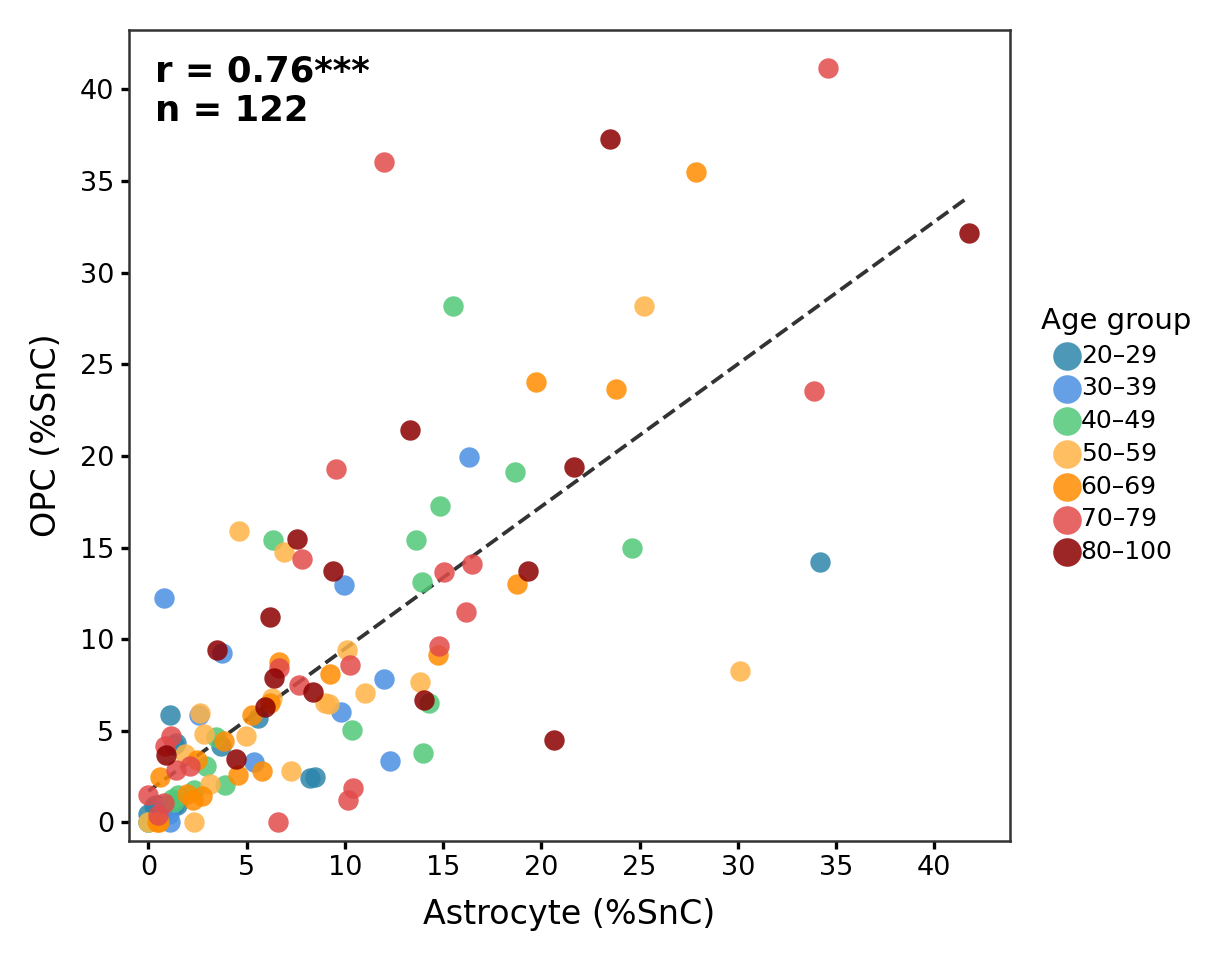

In [14]:
# Figure 2G
SRC       = 'results/fig2G_source_data.csv'
COLOR_BY  = 'age_group'
GRP_ORDER = STUDY_GROUP_ORDER              # from the setup cell
S_PT, ALPHA = 24, 0.85
FIGSIZE   = (4.2, 3.3)
FS        = 8

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

d = pd.read_csv(SRC)
x, y = d.astrocyte_pct.values, d.opc_pct.values
r, p = stats.pearsonr(x, y)
n = len(d)
print(f'n = {n}   r = {r:.3f}   p = {p:.2e}')
print(d[COLOR_BY].value_counts().reindex(GRP_ORDER).to_string())

levels = [g for g in GRP_ORDER if g in set(d[COLOR_BY])]
cols   = color_for('study_group', levels)

fig, ax = plt.subplots(figsize=FIGSIZE)
for lv, c in zip(levels, cols):
    s = d[d[COLOR_BY] == lv]
    ax.scatter(s.astrocyte_pct, s.opc_pct, s=S_PT, c=c, alpha=ALPHA, lw=0,
               zorder=3, label=lv.replace('Age_', '').replace('_', '–'))

m, b = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, m * xs + b, ls='--', color='#333', lw=0.9, zorder=2)

stars = '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < .05 else 'ns'
ax.text(0.03, 0.97, f'r = {r:.2f}{stars}\nn = {n}', transform=ax.transAxes,
        ha='left', va='top', fontsize=FS + 0.5, fontweight='bold')

ax.set_xlabel('Astrocyte (%SnC)', fontsize=FS)
ax.set_ylabel('OPC (%SnC)', fontsize=FS)
ax.tick_params(labelsize=FS - 1.5, length=2, pad=1.5)
ax.set_xlim(left=min(0, x.min() - 1)); ax.set_ylim(bottom=min(0, y.min() - 1))
for sp in ax.spines.values():
    sp.set_visible(True); sp.set_linewidth(0.6); sp.set_color('#333333')
ax.legend(fontsize=FS - 2, frameon=False, loc='center left',
          bbox_to_anchor=(1.01, 0.5), handletextpad=0.3, labelspacing=0.35,
          markerscale=1.4, title='Age group', title_fontsize=FS - 1)

fig.tight_layout()
plt.show()

# Figure 2H

direction               Down     Up
cell_type  senescence              
Astrocytes Non-SnC      45.0  109.0
           SnC           8.0   22.0
OPCs       Non-SnC     137.0  114.0
           SnC           4.0    6.0


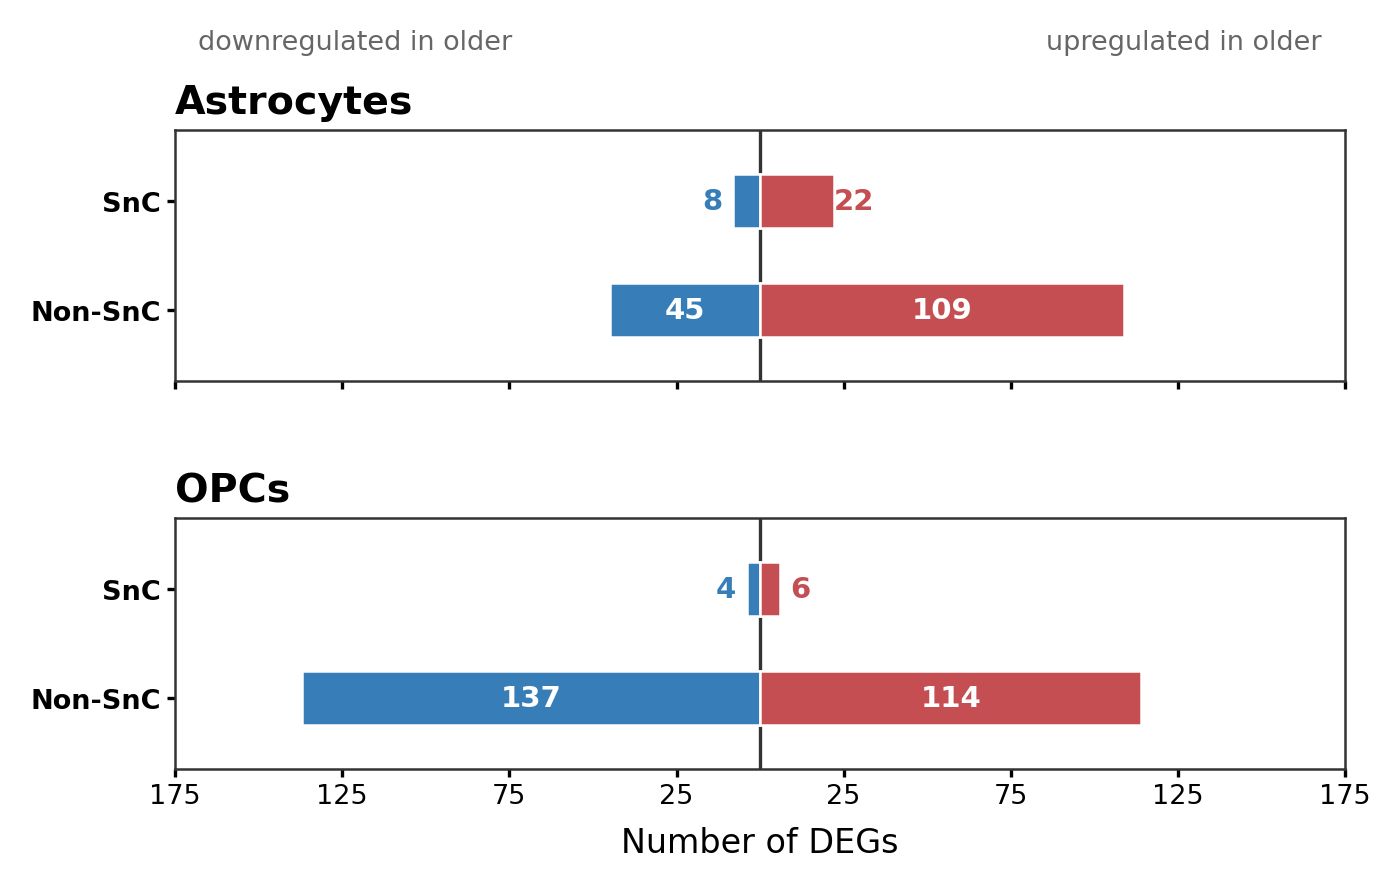

In [13]:
# Figure 2H
SRC        = 'results/fig2H_source_data.csv'
CT_ORDER   = ['Astrocytes', 'OPCs']
SEN_ORDER  = ['SnC', 'Non-SnC']            # top to bottom within each panel
BAR_H      = 0.5
LABEL_IN   = 40                            # counts >= this are drawn inside the bar
SHARE_X    = True                          # same scale in both panels
FIGSIZE    = (5.0, 2.8)
FS         = 8

import numpy as np, pandas as pd, matplotlib.pyplot as plt

d = pd.read_csv(SRC)
print(d.pivot_table(index=['cell_type', 'senescence'], columns='direction',
                    values='n_genes')[['Down', 'Up']].to_string())

d['x'] = np.where(d.direction == 'Down', -d.n_genes, d.n_genes)
lim = np.ceil(d.n_genes.max() / 25) * 25 + 25

fig, axes = plt.subplots(len(CT_ORDER), 1, figsize=FIGSIZE,
                         sharex=SHARE_X, gridspec_kw=dict(hspace=0.55))

for ax, ct in zip(np.atleast_1d(axes), CT_ORDER):
    sub = d[d.cell_type == ct]
    y = np.arange(len(SEN_ORDER))
    for i, sen in enumerate(SEN_ORDER):
        for dr in ('Down', 'Up'):
            r = sub[(sub.senescence == sen) & (sub.direction == dr)].iloc[0]
            ax.barh(y[i], r.x, height=BAR_H, color=r.colour,
                    edgecolor='white', lw=0.6, zorder=2)
            n, inside = int(r.n_genes), int(r.n_genes) >= LABEL_IN
            ax.text(r.x * (0.5 if inside else 1) +
                    (0 if inside else np.sign(r.x) * lim * 0.035),
                    y[i], f'{n}', ha='center', va='center', fontsize=FS - 1,
                    fontweight='bold', color='white' if inside else r.colour,
                    zorder=3)

    ax.axvline(0, color='#333', lw=0.8, zorder=1)
    ax.set_yticks(y); ax.set_yticklabels(SEN_ORDER, fontsize=FS, fontweight='bold')
    ax.set_ylim(len(SEN_ORDER) - 0.35, -0.65)
    ax.set_xlim(-lim, lim)
    ax.set_title(ct, fontsize=FS + 1.5, fontweight='bold', loc='left', pad=4)
    ax.tick_params(labelsize=FS - 1.5, length=2, pad=1.5)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_linewidth(0.6); sp.set_color('#333333')

ticks = np.arange(-lim, lim + 1, 50)
axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels([f'{abs(int(t))}' for t in ticks], fontsize=FS - 1.5)
axes[-1].set_xlabel('Number of DEGs', fontsize=FS)

axes[0].text(0.02, 1.30, 'downregulated in older', transform=axes[0].transAxes,
             fontsize=FS - 1.5, color='#666', ha='left', va='bottom')
axes[0].text(0.98, 1.30, 'upregulated in older', transform=axes[0].transAxes,
             fontsize=FS - 1.5, color='#666', ha='right', va='bottom')

fig.tight_layout()
plt.show()